# 4.5 EDA and Preparing Data for Machine Learning Models Lab

## Dataset choice
For this lab, I used the **California housing dataset** from `housing.csv`.

This dataset is appropriate for the assignment because it has:
- more than a few hundred rows,
- multiple quantitative and categorical features,
- one clear target feature for prediction.

## Target feature
The **target feature** is `median_house_value`, which represents the median home value for each district.

## Features in the dataset
- `longitude`
- `latitude`
- `housing_median_age`
- `total_rooms`
- `total_bedrooms`
- `population`
- `households`
- `median_income`
- `ocean_proximity`
- `median_house_value` (**target**)

## Goal
The goal of this exploratory data analysis is to identify which features appear most related to `median_house_value` and to note what preprocessing steps would be useful before building a machine learning model.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../../Lab/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
df.shape, df.dtypes

((20640, 10),
 longitude             float64
 latitude              float64
 housing_median_age    float64
 total_rooms           float64
 total_bedrooms        float64
 population            float64
 households            float64
 median_income         float64
 median_house_value    float64
 ocean_proximity        object
 dtype: object)

## Initial data check

First, I checked the size of the dataset, the data types, and whether any missing values were present. Missing values matter because they must usually be handled before training a machine learning model.


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
df.isna().sum().sort_values(ascending=False)

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### Missing data interpretation
The dataset has **missing values in `total_bedrooms`**, while the other features appear complete. This means the data will likely need an imputation step before modeling. A simple option would be to fill missing bedroom counts with the median, although a more advanced strategy could also be used.


## Visualization 1: Distribution of the target feature

I started by looking at the distribution of `median_house_value` so I could understand the target before comparing it to other features.


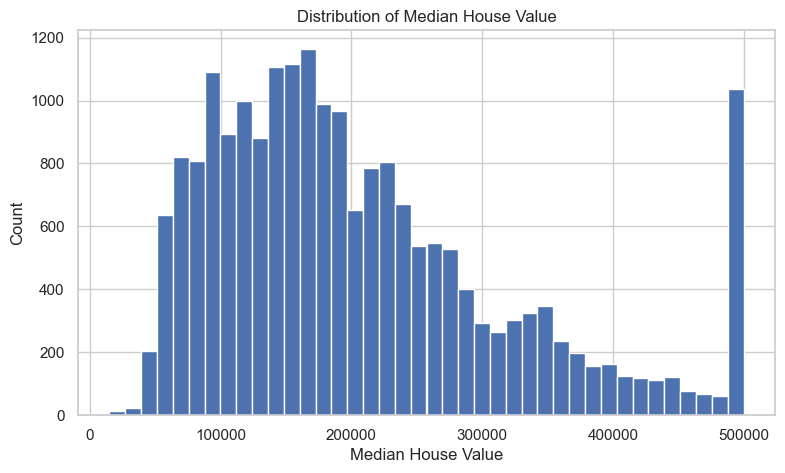

In [10]:
plt.figure(figsize=(9,5))
plt.hist(df["median_house_value"].dropna(), bins=40)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

### Interpretation 1
The target is not perfectly symmetric. It is concentrated in the lower and middle value ranges, with fewer very high-value districts. There also appears to be a sharp upper cap near the high end, which suggests some values may have been top-coded. This matters for machine learning because the capped values can make the relationship between predictors and the target less smooth.


## Visualization 2: Median income vs. median house value

`median_income` is often one of the strongest predictors of housing prices, so I compared it directly with the target.


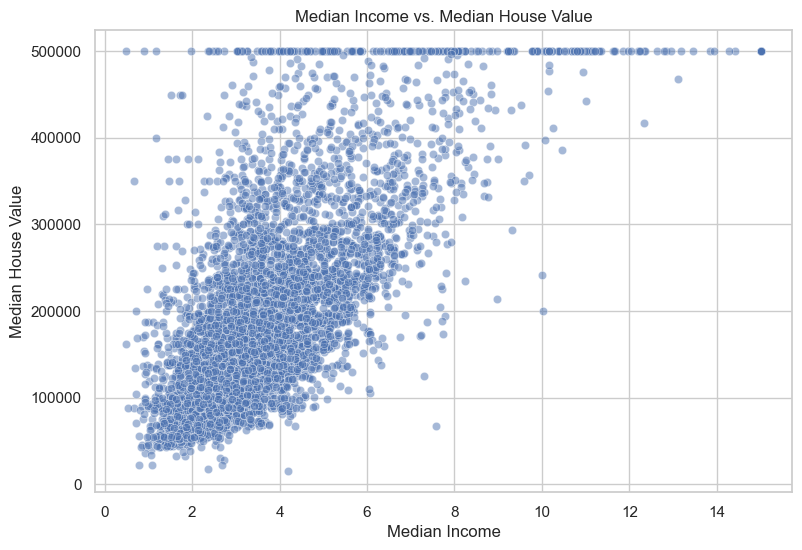

In [11]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df.sample(5000, random_state=42), x="median_income", y="median_house_value", alpha=0.5)
plt.title("Median Income vs. Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

### Interpretation 2
There is a clear **positive relationship** between `median_income` and `median_house_value`. As neighborhood income increases, home values generally increase as well. This looks like one of the strongest relationships in the dataset, although the pattern is not perfectly linear and the upper-value cap is visible here too.


## Visualization 3: Ocean proximity vs. median house value

Because location is very important in real estate, I compared the categorical location feature `ocean_proximity` to the target.


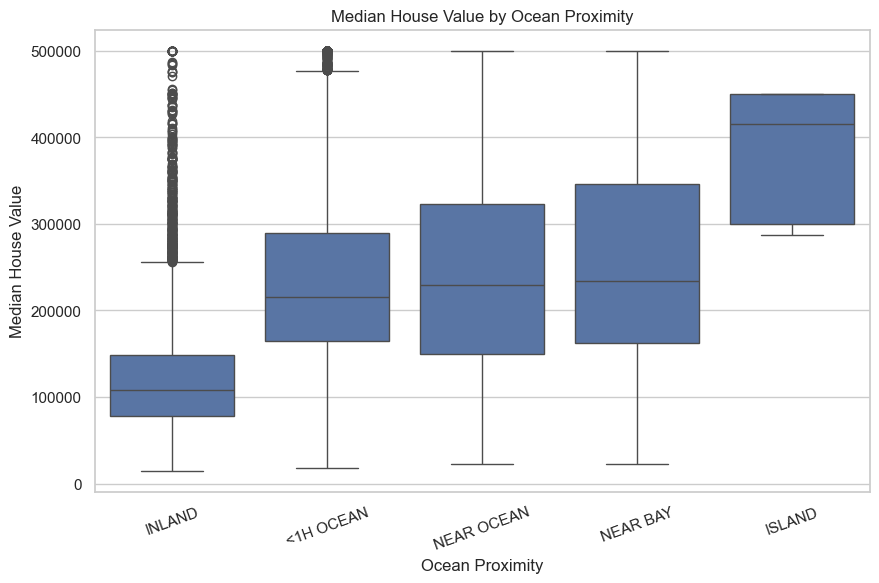

In [12]:
plt.figure(figsize=(10,6))
order = df.groupby("ocean_proximity")["median_house_value"].median().sort_values().index
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", order=order)
plt.title("Median House Value by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")
plt.xticks(rotation=20)
plt.show()

### Interpretation 3
`ocean_proximity` shows a meaningful relationship with the target. Districts that are **near the ocean or near the bay** tend to have higher home values, while inland districts tend to have lower values. This suggests the categorical location feature should be retained for modeling and encoded appropriately, such as with one-hot encoding.


## Visualization 4: Latitude and longitude colored by median house value

To better understand the spatial pattern of prices, I plotted districts by location and colored them by the target.


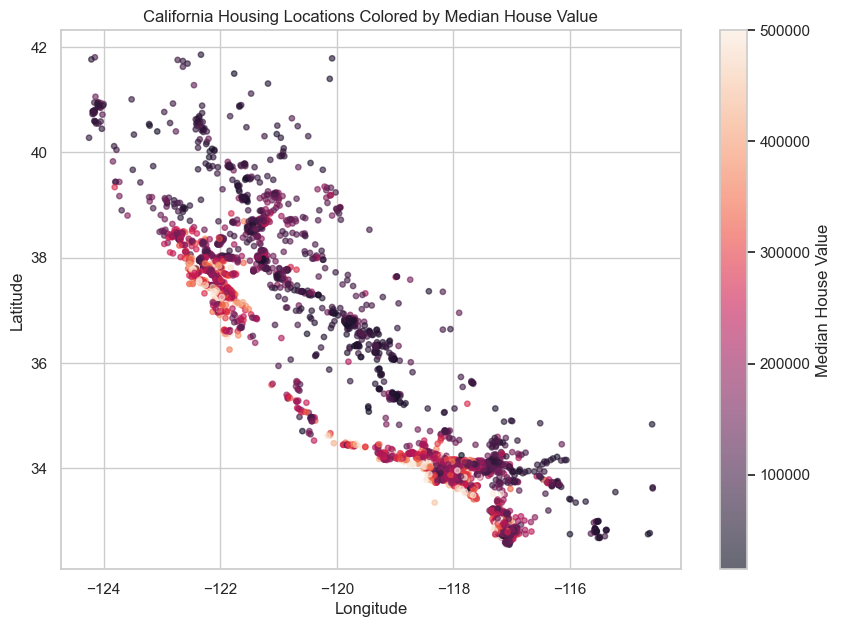

In [13]:
plt.figure(figsize=(10,7))
sample_df = df.sample(5000, random_state=42)
plt.scatter(sample_df["longitude"], sample_df["latitude"],
            c=sample_df["median_house_value"], s=15, alpha=0.6)
plt.colorbar(label="Median House Value")
plt.title("California Housing Locations Colored by Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Interpretation 4
The spatial plot shows that home values are not randomly distributed. Higher-value districts cluster in certain parts of the map, especially in coastal areas. This tells me that **geographic position is strongly related to house value**, and it also suggests that location variables may interact with other features such as income and ocean proximity.


## Visualization 5: Housing median age vs. median house value

Next, I looked at whether the age of the housing stock appears related to price.


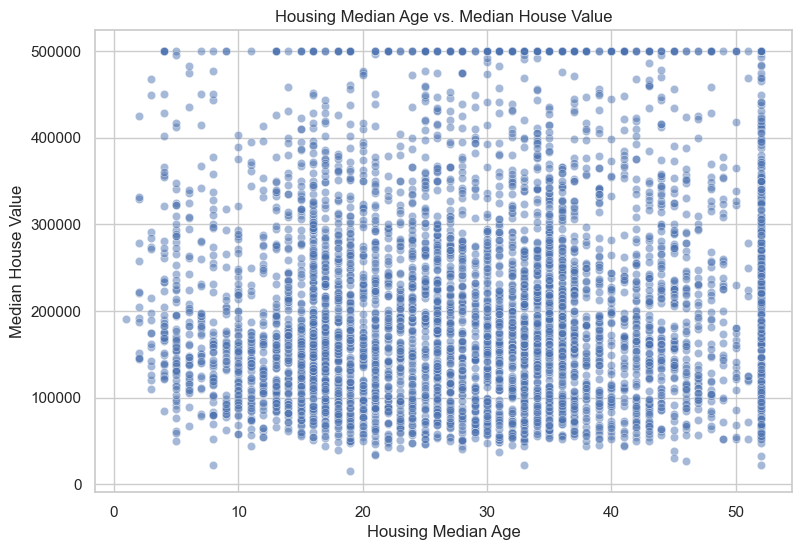

In [14]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df.sample(5000, random_state=7), x="housing_median_age", y="median_house_value", alpha=0.5)
plt.title("Housing Median Age vs. Median House Value")
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.show()

### Interpretation 5
The relationship between `housing_median_age` and `median_house_value` appears weaker than the relationship with income, but it is not random. Some older areas have relatively high prices, possibly because they are in desirable locations. This feature may still contribute useful information to a model, but it does not look like the strongest standalone predictor.


## Visualization 6: Total rooms vs. median house value

I also compared one housing-size feature with the target to see whether larger districts tend to have more expensive homes.


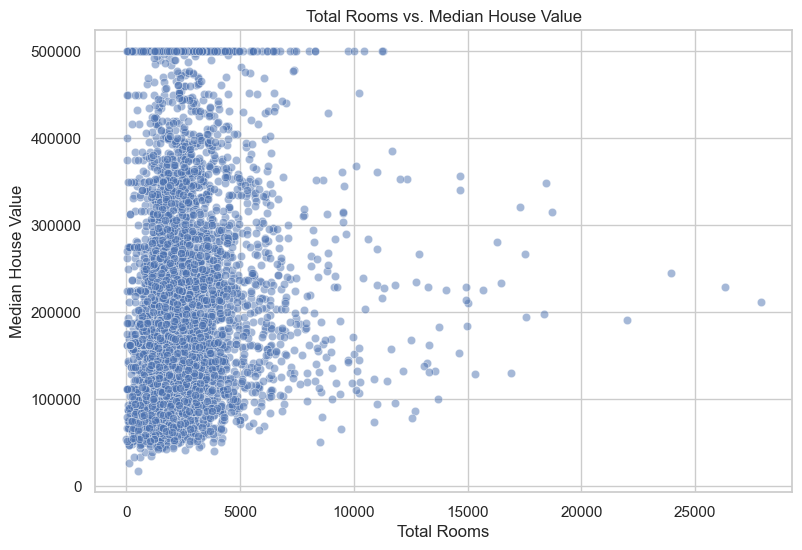

In [15]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df.sample(5000, random_state=11), x="total_rooms", y="median_house_value", alpha=0.5)
plt.title("Total Rooms vs. Median House Value")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.show()

### Interpretation 6
`total_rooms` has a **weak-to-moderate relationship** with `median_house_value`, but the pattern is noisy. On its own, total room count does not explain price nearly as well as income or location. This suggests that raw room counts may be more useful after feature engineering, such as creating ratios like rooms per household or bedrooms per room.


## Correlation check for numeric features

To summarize the numeric relationships, I calculated a correlation matrix for the quantitative columns.


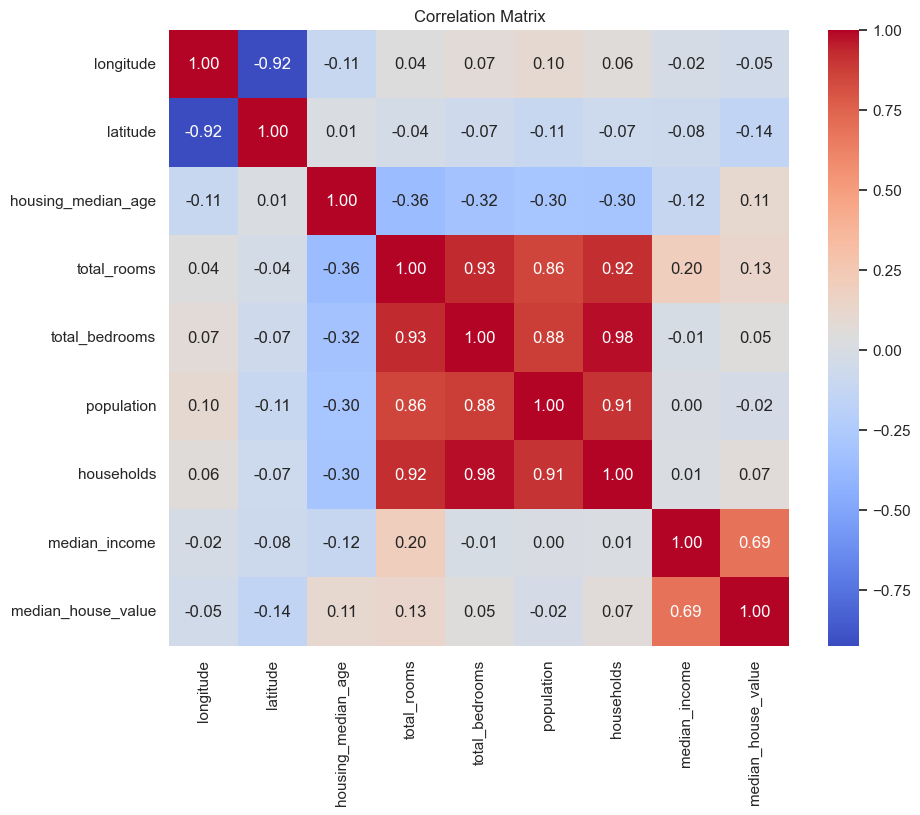

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [16]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

corr["median_house_value"].sort_values(ascending=False)

### Correlation interpretation
Among the numeric features, `median_income` has the strongest positive relationship with `median_house_value`. Location-related variables also matter, though their relationships are not fully captured by simple linear correlation alone. Features like `total_rooms`, `population`, and `households` show weaker direct relationships with the target.


## Preparing the data for machine learning

Based on the EDA, these preprocessing steps would be appropriate before training a model:

1. **Handle missing values** in `total_bedrooms`, such as by median imputation.
2. **Encode the categorical feature** `ocean_proximity` using one-hot encoding.
3. **Consider feature scaling** for models that are sensitive to scale.
4. **Create engineered features** such as:
   - rooms per household,
   - bedrooms per room,
   - population per household.
5. **Split the data** into training and test sets before fitting a model.


In [17]:
# Example of simple feature engineering
prep_df = df.copy()

prep_df["rooms_per_household"] = prep_df["total_rooms"] / prep_df["households"]
prep_df["bedrooms_per_room"] = prep_df["total_bedrooms"] / prep_df["total_rooms"]
prep_df["population_per_household"] = prep_df["population"] / prep_df["households"]

prep_df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].head()

,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


## Conclusion

Overall, the features that appear **most related** to `median_house_value` are:
- `median_income`
- `ocean_proximity`
- geographic location (`latitude` and `longitude`)

The features that appear **less strongly related on their own** include:
- `housing_median_age`
- `total_rooms`

The big picture takeaway is that **income and location are the main drivers of housing value in this dataset**. Before building a machine learning model, the data should be cleaned by handling missing bedroom values and encoding the categorical location feature. Additional engineered features could further improve model performance.
